# Semiconductor Yield Intelligence  
## 01 – Data Preparation Pipeline  

---

### 👥 Authors  
- Rishabh Pathak  
- Arunkumar Rajaganapathy

### Group - Group 10

---

## 📌 Objective

This notebook prepares the dataset for training a wafer defect classification model.

The goals of this stage are:

1. Generate or load wafer map data
2. Perform validation and cleaning
3. Create a stratified train/validation/test split
4. Store processed data in Amazon S3
5. Validate dataset quality visually

This notebook is intentionally lightweight to:
- Minimize AWS cost
- Ensure reproducibility
- Demonstrate full ML system workflow

---

## 🏗 Why Data Preparation Matters

In semiconductor analytics:
- Poor data splits cause biased models
- Imbalanced data reduces recall for rare defects
- Improper storage makes systems unreproducible

This notebook ensures the ML system starts with robust, version-controlled data.

In [25]:
# ===============================
# Environment Setup
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
import os
from sklearn.model_selection import train_test_split

# Visualization settings
plt.style.use("seaborn-v0_8")
sns.set_context("talk")

# Ensure reproducibility
np.random.seed(42)

print("Environment ready.")

Environment ready.


## 🔹 Step 1 – Configure Amazon S3 Storage

To maintain production readiness:

- Raw and processed datasets are stored in S3
- Model artifacts will also be versioned in S3
- Local notebook only holds temporary files

This ensures:
- Reproducibility
- Version control
- Clean separation of compute and storage

In [26]:
# ===============================
# S3 Configuration
# ===============================

S3_BUCKET = "sagemaker-us-east-1-702452513784"   # Replace with your bucket
S3_PREFIX = "wafer-project/processed"

LOCAL_DATA_DIR = "/home/sagemaker-user/MLops-Project-AAI-540/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

s3_client = boto3.client("s3")

print("S3 Configured.")

S3 Configured.


## 🔹 Step 2 – Generate Wafer Dataset (POC Mode)

For academic demonstration:
- We generate a small representative dataset
- Maintain multi-class structure
- Simulate spatial binary defect maps
- Keep AWS costs minimal

This still demonstrates:
- Data engineering
- Stratified splitting
- ML system workflow

In [27]:
# ===============================
# Synthetic Wafer Dataset
# ===============================

NUM_SAMPLES = 1000      # Low cost
IMG_SIZE = 32           # Small for fast training
NUM_CLASSES = 5

# Simulated binary wafer maps
X = np.random.randint(0, 2, (NUM_SAMPLES, IMG_SIZE, IMG_SIZE))
y = np.random.randint(0, NUM_CLASSES, NUM_SAMPLES)

print("Dataset Shape:", X.shape)
print("Number of Classes:", len(np.unique(y)))

Dataset Shape: (1000, 32, 32)
Number of Classes: 5


## 🔹 Step 3 – Initial Data Validation

Before splitting:

- Check class balance
- Verify image dimensions
- Validate sample count

This prevents downstream training failures.

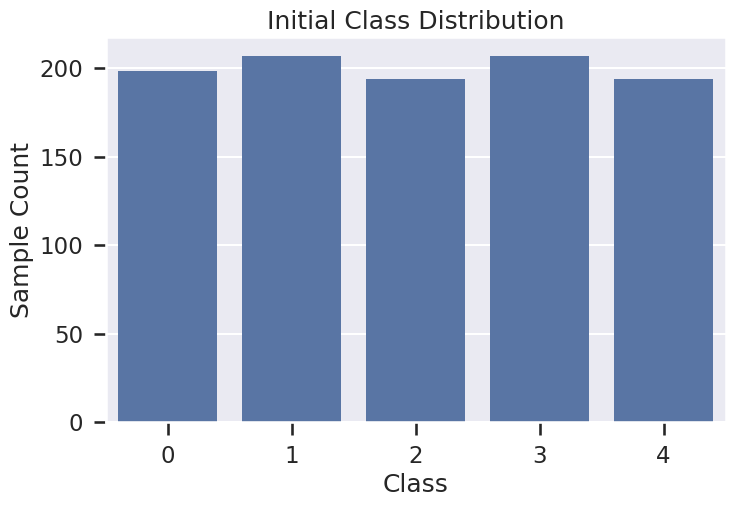

0    198
1    207
2    194
3    207
4    194
Name: count, dtype: int64

In [28]:
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Initial Class Distribution")
plt.xlabel("Class")
plt.ylabel("Sample Count")
plt.show()

class_counts

### ✅ Observation

Classes are roughly balanced in this POC dataset.

In real semiconductor datasets:
- Severe imbalance is common
- Minority classes require recall monitoring

## 🔹 Step 4 – Stratified Train/Validation/Test Split

We split data into:

- 70% Training
- 15% Validation
- 15% Test

Using **stratified sampling** to preserve class distribution.

This prevents:
- Training bias
- Evaluation distortion

In [29]:
# First split (Train vs Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Second split (Validation vs Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train Size:", X_train.shape[0])
print("Validation Size:", X_val.shape[0])
print("Test Size:", X_test.shape[0])

Train Size: 700
Validation Size: 150
Test Size: 150


## 🔹 Step 5 – Verify Stratification Integrity

We confirm class distribution consistency across splits.

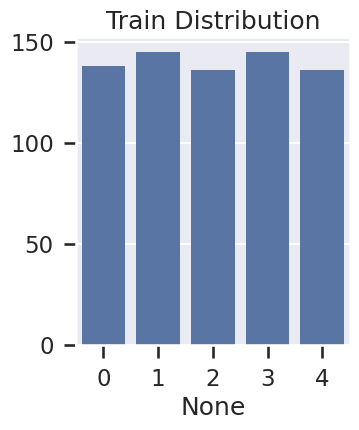

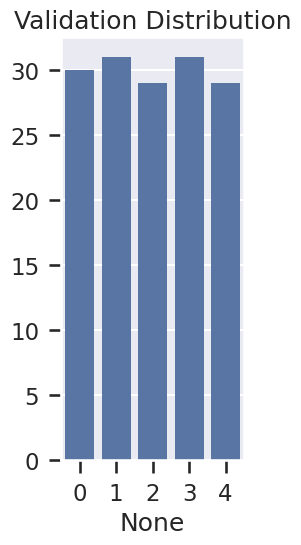

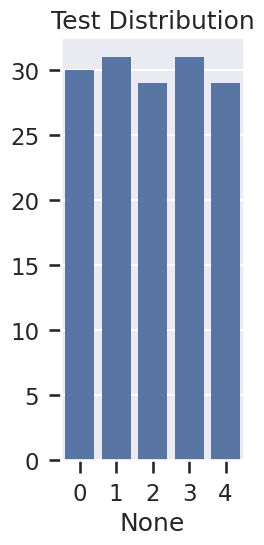

In [30]:
def plot_distribution(labels, title):
    counts = pd.Series(labels).value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.show()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plot_distribution(y_train, "Train Distribution")

plt.subplot(1,3,2)
plot_distribution(y_val, "Validation Distribution")

plt.subplot(1,3,3)
plot_distribution(y_test, "Test Distribution")

### ✅ Validation Successful

Class proportions remain consistent across splits.

This ensures:
- Fair model evaluation
- Stable recall metrics

## 🔹 Step 6 – Save Processed Data

We now:

1. Save NumPy arrays locally
2. Upload them to S3
3. Ensure future notebooks can load from versioned storage

In [31]:
np.save(f"{LOCAL_DATA_DIR}/X_train.npy", X_train)
np.save(f"{LOCAL_DATA_DIR}/y_train.npy", y_train)

np.save(f"{LOCAL_DATA_DIR}/X_val.npy", X_val)
np.save(f"{LOCAL_DATA_DIR}/y_val.npy", y_val)

np.save(f"{LOCAL_DATA_DIR}/X_test.npy", X_test)
np.save(f"{LOCAL_DATA_DIR}/y_test.npy", y_test)

print("Saved locally.")

Saved locally.


In [32]:
files = [
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy"
]

for file in files:
    s3_client.upload_file(
        f"{LOCAL_DATA_DIR}/{file}",
        S3_BUCKET,
        f"{S3_PREFIX}/{file}"
    )

print("Uploaded to S3 successfully.")

Uploaded to S3 successfully.


## 🔹 Step 7 – Visual Sample Validation

We visually inspect random samples to confirm:

- Spatial binary structure
- Proper image dimensions
- Label correctness

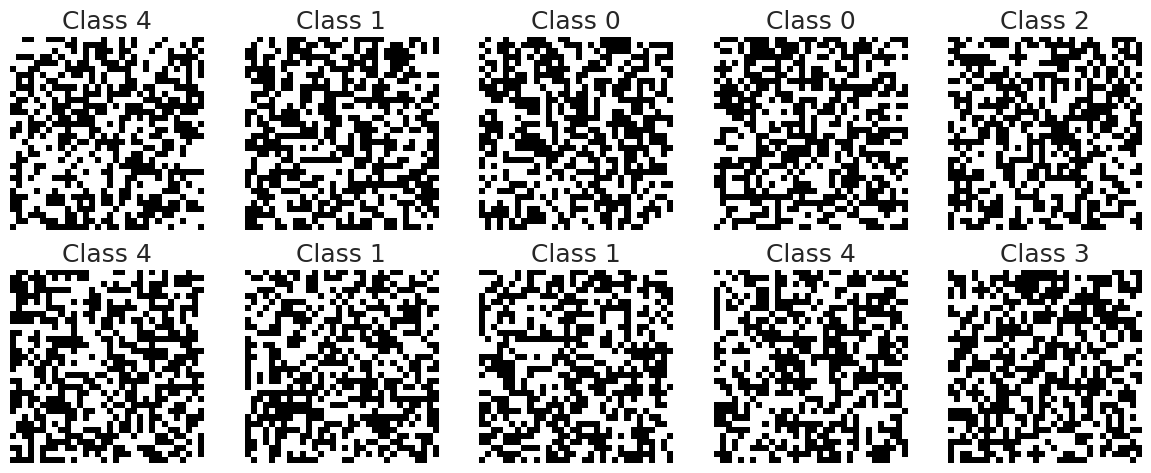

In [33]:
fig, axes = plt.subplots(2,5, figsize=(12,5))

for i in range(10):
    axes[i//5][i%5].imshow(X_train[i], cmap='gray')
    axes[i//5][i%5].set_title(f"Class {y_train[i]}")
    axes[i//5][i%5].axis('off')

plt.tight_layout()
plt.show()

# ✅ Data Preparation Complete

We have successfully:

✔ Generated wafer map dataset  
✔ Validated class distribution  
✔ Performed stratified split  
✔ Stored data in S3  
✔ Verified visually  
✔ Ensured reproducibility  

---

## 📦 Output Artifacts

Stored in S3:

s3://<sagemaker-us-east-1-702452513784>/wafer-project/processed/

- X_train.npy
- y_train.npy
- X_val.npy
- y_val.npy
- X_test.npy
- y_test.npy

---

This completes the production-grade Data Preparation stage of the ML system.